#### 과일 Data를 CNN으로 Image 분류

In [2]:
import warnings
warnings.filterwarnings('ignore')


In [3]:
# 과일 데이터 불러오기
import numpy as np

fruits = np.load("../Data/fruits.npy")
fruits.shape # 결과의 맨 앞부분이 페이지임

(300, 100, 100)

In [4]:
fruits.shape[0]

300

In [5]:
len(fruits)

300

In [6]:
fruits[200].shape

(100, 100)

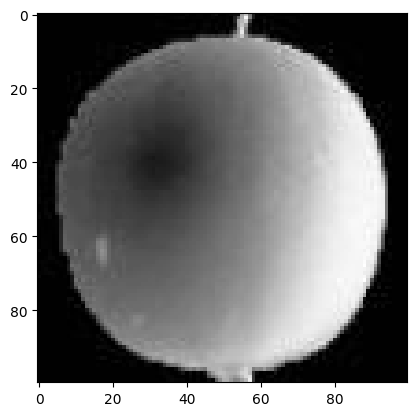

In [7]:
# Image 확인하기
import matplotlib .pyplot as plt

plt.imshow(fruits[0].reshape(100,100), cmap='gray')
plt.show()

In [8]:
# Target 만들기
target = np.concatenate(
    [
        np.zeros(100), # 넘파이로 0을 100개 만든거 
        np.ones(100),
        np.full(100,2) # 100개만든다 , 2로  ( 넘파이 2는 없어서 )
    ]
)

target.shape

# 타겟이 없어서 100개씩 0,1,2 를 타겟으로 만들어줌 ( 사진 각각에 타겟을 붙여주려고)

(300,)

In [65]:
target

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 2., 2., 2., 2.,
       2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
       2., 2., 2., 2., 2.

1. Train 과 Test로 분류하기
2. CNN 만들기
3. 시각화  (손실 (loss와 valloss))
4. 평가 

In [10]:
from PIL import Image


In [11]:
for i in range(300):
    image = Image.fromarray(fruits[i]).convert("L")
    image.save(f"../Data/fruits/friuit_{i:03d}.jpg","JPEG")

# %%
numberOfData = 300
imgSize = 100

# %%
# 배열 초기화
fruitsData = np.zeros(numberOfData * imgSize * imgSize,dtype=np.int32).reshape(numberOfData, imgSize, imgSize)
fruitsData

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [12]:
import glob
from PIL import Image
import matplotlib.pyplot as plt

In [13]:
train_images = glob.glob('../data/fruits/*.jpg') # 데이터가 아니라, file name을 가지고 옴

In [15]:
train_images[:5] # file name이 잘 가지고 왔는지 확인

['../data/fruits/friuit_101.jpg',
 '../data/fruits/friuit_115.jpg',
 '../data/fruits/friuit_129.jpg',
 '../data/fruits/friuit_277.jpg',
 '../data/fruits/friuit_263.jpg']

In [17]:
print(len(train_images))
print(len(target))

300
300


In [26]:
# 분리
from sklearn.model_selection import train_test_split

# train_scaled = train_scaled.reshape(-1, 28 * 28) #  이건 했으니까 안해도 되고

train_data, test_data, train_target, test_target = train_test_split(
                                                        train_images,
                                                        target, 
                                                        test_size=0.2, 
                                                        random_state=42
)

In [43]:
X_train = []
X_test = []
y_train = []
y_test = []

# train data
for image in sorted(train_data):
    img = Image.open(image)
    imgResize = img.resize((100, 100), Image.Resampling.LANCZOS) # 이미지 사이즈 변경 , Resampling.LANCZOS : 고품질의 리샘플링 방법(깨지지 않게 만드는 거 )
    X_train.append(imgResize) # 이미지 데이터를 리스트에 추가 _input
    y_train.append(image[-7:-4]) # target _ 두글자만 따와서 넣음


# # test data
# for image in sorted(test_data):
#     img = Image.open(image)
#     imgResize = img.resize((100, 100), Image.Resampling.LANCZOS) # 이미지 사이즈 변경 , Resampling.LANCZOS : 고품질의 리샘플링 방법(깨지지 않게 만드는 거 )
#     X_test.append(imgResize) # 이미지 데이터를 리스트에 추가
#     y_test.append(image[-6:-4])

y_train = []

for image in sorted(train_images):
    img = Image.open(image)
    imgResize = img.resize((32, 32), Image.Resampling.LANCZOS)
    X_train.append(imgResize)

    label_num = int(image[-7:-4])
    y_train.append(label_num // 100 + 1)


In [44]:
y_train

[1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,


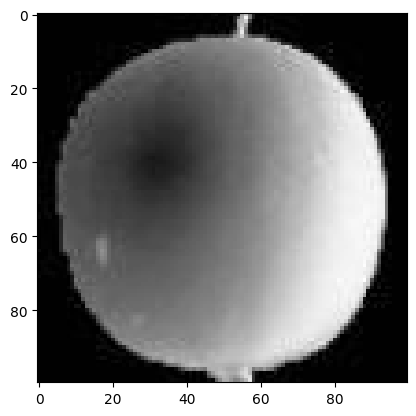

In [35]:
# train의 이미지 확인 
plt.imshow(X_train[0], cmap='gray')
plt.show()

In [36]:
# train data 만들기
tempData = np.zeros(# 3차원 데이터로 바꿔줌
                300 * 100 * 100, #
                dtype=np.int32
).reshape(300, 100, 100) # 18000장의 이미지를 32x32 픽셀로 변환

i = 0
for image in X_train:
    img = np.array(image, dtype=np.int32)
    tempData[i,:,:] = img # 0에 이미지 하나 들어가는데, 나머지는 너가 알아서 하라고 정해줌
    i+=1

X_train = tempData.copy()

In [39]:
# test data 만들기
tempData = np.zeros(
                300 * 100 * 100, 
                dtype=np.int32
).reshape(300, 100, 100)

i = 0
for image in X_test:
    img = np.array(image, dtype=np.int32)
    tempData[i,:,:] = img
    i+=1

X_test = tempData.copy()

In [40]:
print(X_train.shape, X_test.shape)

(300, 100, 100) (300, 100, 100)


In [41]:
# 배열 크기 확인
print(X_train.shape, X_test.shape)

(300, 100, 100) (300, 100, 100)


In [42]:
y_train[:5]

['000', '001', '004', '006', '007']

In [46]:
y_train = np.array(y_train)
y_test = np.array(y_test)

In [47]:
y_train[:5]

array([1, 1, 1, 1, 1])

In [49]:
X_train

[<PIL.Image.Image image mode=L size=100x100>,
 <PIL.Image.Image image mode=L size=100x100>,
 <PIL.Image.Image image mode=L size=100x100>,
 <PIL.Image.Image image mode=L size=100x100>,
 <PIL.Image.Image image mode=L size=100x100>,
 <PIL.Image.Image image mode=L size=100x100>,
 <PIL.Image.Image image mode=L size=100x100>,
 <PIL.Image.Image image mode=L size=100x100>,
 <PIL.Image.Image image mode=L size=100x100>,
 <PIL.Image.Image image mode=L size=100x100>,
 <PIL.Image.Image image mode=L size=100x100>,
 <PIL.Image.Image image mode=L size=100x100>,
 <PIL.Image.Image image mode=L size=100x100>,
 <PIL.Image.Image image mode=L size=100x100>,
 <PIL.Image.Image image mode=L size=100x100>,
 <PIL.Image.Image image mode=L size=100x100>,
 <PIL.Image.Image image mode=L size=100x100>,
 <PIL.Image.Image image mode=L size=100x100>,
 <PIL.Image.Image image mode=L size=100x100>,
 <PIL.Image.Image image mode=L size=100x100>,
 <PIL.Image.Image image mode=L size=100x100>,
 <PIL.Image.Image image mode=L siz

In [50]:
X_train = []
X_test = []
y_train = []
y_test = []


for image in sorted(train_images):
    img = Image.open(image).convert("L")
    imgResize = img.resize((32, 32), Image.Resampling.LANCZOS)

    X_train.append(np.array(imgResize))

    label_num = int(image[-7:-4])
    y_train.append(label_num // 100)


In [51]:
X_train = np.array(X_train)
y_train = np.array(y_train)


In [52]:
X_train = X_train / 255.0


In [53]:
X_train = X_train.reshape(-1, 32, 32, 1)


In [54]:
print(X_train.shape)
print(y_train.shape)


(300, 32, 32, 1)
(300,)


In [57]:
# train -> train, vaild 분리
from sklearn.model_selection import train_test_split

# train_scaled = train_scaled.reshape(-1, 28 * 28) #  이건 했으니까 안해도 되고

train_scaled, val_scaled, train_target, val_target = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)


In [58]:
from tensorflow import keras
from tensorflow.keras.layers import Input
# 입력층 : 1024
# 은닉층 : 32
# 출력층 : 11
# activation : signoid, tanh ,relu,leakyRelu


# model = keras.Sequential()
# model.add(Input(shape=(784,)))
# model.add(keras.layers.Dense(1284,activation='relu')) # 은닉층 : 2의 배수
# model.add(keras.layers.Dense(10,activation='softmax'))


# model = keras.Sequential()
# model.add(keras.layers.Flatten(input_shape=(32, 32)))
# model.add(keras.layers.Dense(128, activation='relu')) 
# model.add(keras.layers.Dense(12, activation='softmax'))


model = keras.Sequential()
model.add(keras.layers.Flatten(input_shape=(32, 32))) # 들어올게  32*32로 들어올 거야
model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dense(12, activation='softmax'))



In [59]:

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [61]:
hist = model.fit(
    train_data,
    train_target,
    epochs=5,
    validation_data=(val_scaled, val_target)
)


Epoch 1/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.4583 - loss: 1.3282 - val_accuracy: 0.9333 - val_loss: 0.6552
Epoch 2/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9292 - loss: 0.4605 - val_accuracy: 0.9833 - val_loss: 0.2688
Epoch 3/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9667 - loss: 0.2120 - val_accuracy: 1.0000 - val_loss: 0.1351
Epoch 4/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.1130 - val_accuracy: 1.0000 - val_loss: 0.0804
Epoch 5/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 0.0710 - val_accuracy: 1.0000 - val_loss: 0.0410


In [62]:
model.evaluate(np.array(train_scaled),np.array(train_target))

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.0512 


[0.05115063488483429, 1.0]

In [63]:
model.evaluate(np.array(val_scaled),np.array(val_target))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 1.0000 - loss: 0.0410


[0.041026949882507324, 1.0]